In [1]:
import pandas as pd 
import seaborn as sns 
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
import numpy as np
pd.set_option("display.max_colwidth",None)
pd.set_option("display.max_columns",None)

In [2]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

sns.set(style="whitegrid")

# Project
## Spotify User Behavior And Pattern Recognition Analysis 

In [3]:
df=pd.read_csv(r"/kaggle/input/datasets/sahilislam007/spotify-user-behavior-and-pattern/spotify_user_behavior_realistic_50000_rows.csv")

# Data Info

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 18 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   user_id                         50000 non-null  int64  
 1   country                         50000 non-null  object 
 2   age                             50000 non-null  int64  
 3   signup_date                     50000 non-null  object 
 4   subscription_type               50000 non-null  object 
 5   subscription_status             50000 non-null  object 
 6   months_inactive                 50000 non-null  int64  
 7   inactive_3_months_flag          50000 non-null  int64  
 8   ad_interaction                  50000 non-null  object 
 9   ad_conversion_to_subscription   50000 non-null  object 
 10  music_suggestion_rating_1_to_5  50000 non-null  int64  
 11  avg_listening_hours_per_week    50000 non-null  float64
 12  favorite_genre                  

In [5]:
df.shape

(50000, 18)

# Data Handling & Cleaning

In [6]:
df.isna().sum()
df.duplicated().sum()

np.int64(0)

In [7]:
df.drop(columns=['user_id'],inplace=True)

# Data Preprocessing

In [8]:
df["signup_date"] = pd.to_datetime(df["signup_date"])

df["signup_year"] = df["signup_date"].dt.year
df["signup_month"] = df["signup_date"].dt.month

# EDA & Visualization

In [9]:
df.head()

,country,age,signup_date,subscription_type,subscription_status,months_inactive,inactive_3_months_flag,ad_interaction,ad_conversion_to_subscription,music_suggestion_rating_1_to_5,avg_listening_hours_per_week,favorite_genre,most_liked_feature,desired_future_feature,primary_device,playlists_created,avg_skips_per_day,signup_year,signup_month
0,France,25,2021-08-19,Premium Duo,Active,0,0,No,No,4,10.13,Bollywood,Radio,Concert Alerts,Tablet,7,8,2021,8
1,Indonesia,20,2022-06-06,Premium Family,Active,0,0,Yes,No,5,11.63,Latin,Podcasts,Lyrics Translation,Mobile,7,6,2022,6
2,Italy,53,2024-01-04,Premium Individual,Active,0,0,Yes,Yes,3,9.50,Bollywood,Lyrics,Better AI Recommendations,Desktop,6,5,2024,1
3,Italy,48,2018-08-26,Premium Individual,Active,1,0,No,No,4,13.16,Electronic,Playlists,Social Listening,Smart Speaker,11,8,2018,8
4,Australia,18,2020-05-29,Free,Active,0,0,No,No,4,12.70,Indie,Daily Mix,Lyrics Translation,Tablet,10,11,2020,5


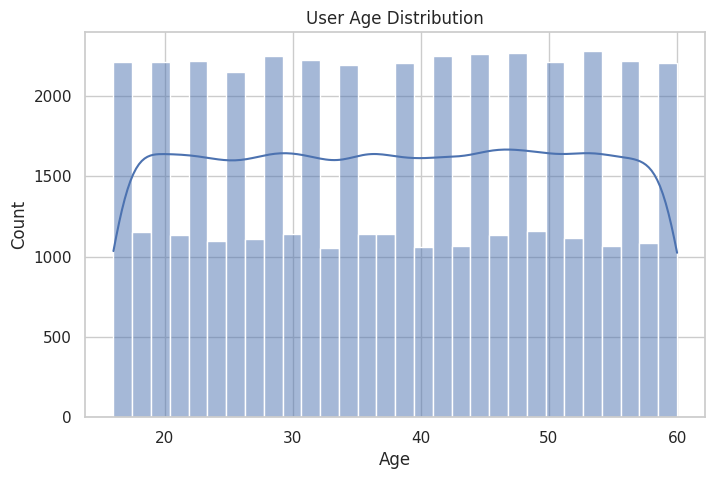

In [10]:
plt.figure(figsize=(8,5))
sns.histplot(df["age"], bins=30, kde=True)

plt.title("User Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")

plt.show()

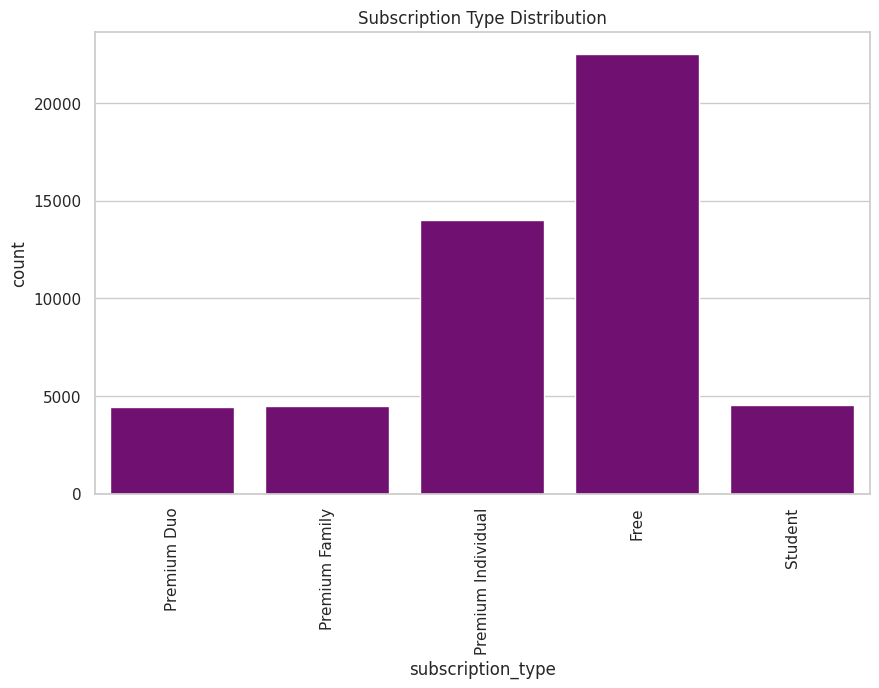

In [11]:
plt.figure(figsize=(10,6))
sns.countplot(data=df, x="subscription_type",color="purple")
plt.xticks(rotation=90)
plt.title("Subscription Type Distribution")
plt.show()

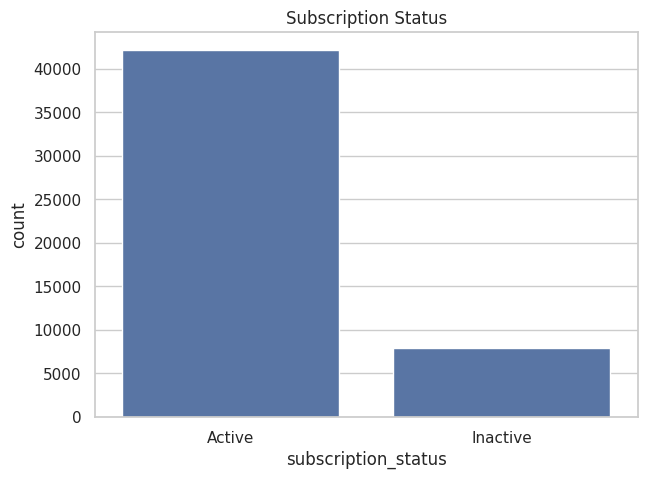

In [12]:
plt.figure(figsize=(7,5))
sns.countplot(data=df, x="subscription_status")

plt.title("Subscription Status")
plt.show()

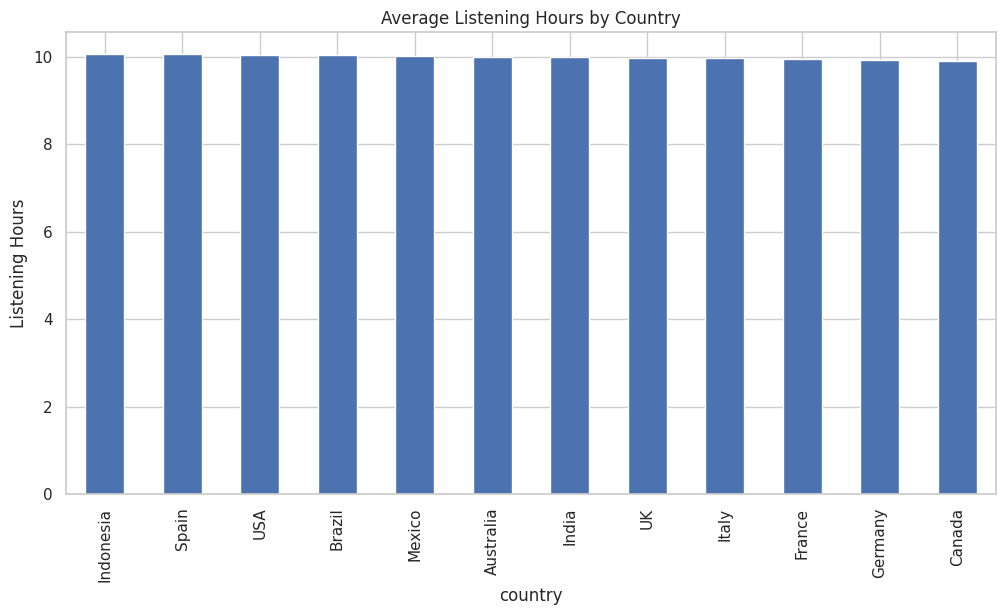

In [13]:
country_listening = df.groupby("country")["avg_listening_hours_per_week"].mean().sort_values(ascending=False)

plt.figure(figsize=(12,6))
country_listening.plot(kind="bar")

plt.title("Average Listening Hours by Country")
plt.ylabel("Listening Hours")

plt.show()

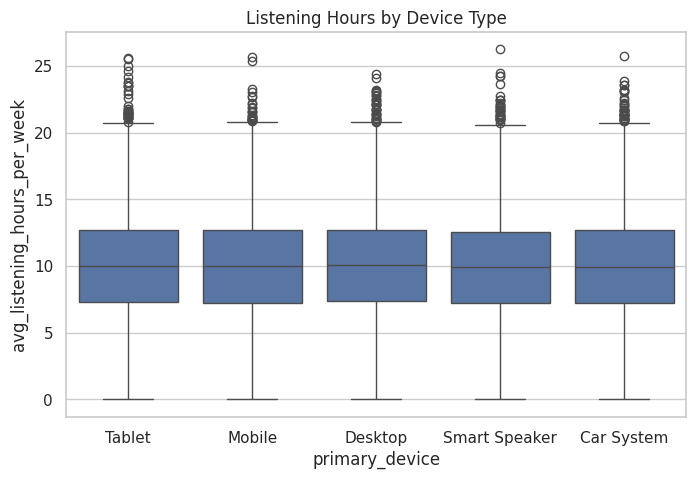

In [14]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="primary_device",
    y="avg_listening_hours_per_week"
)

plt.title("Listening Hours by Device Type")

plt.show()

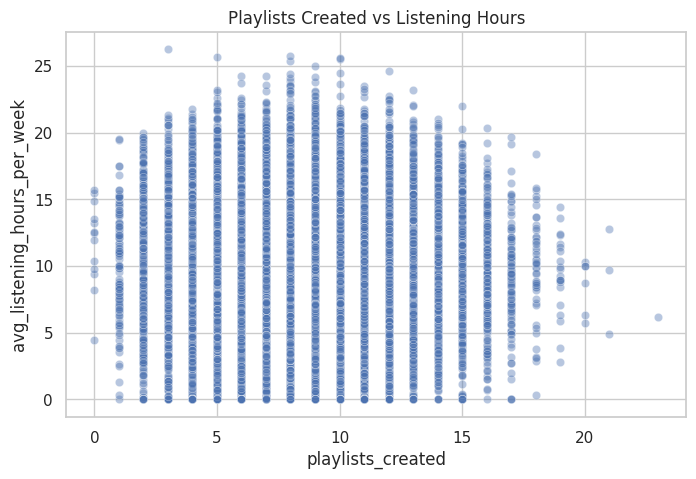

In [15]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="playlists_created",
    y="avg_listening_hours_per_week",
    alpha=0.4
)

plt.title("Playlists Created vs Listening Hours")

plt.show()

In [16]:
df[["playlists_created","avg_listening_hours_per_week"]].corr()

,playlists_created,avg_listening_hours_per_week
playlists_created,1.000000,0.001642
avg_listening_hours_per_week,0.001642,1.000000


In [17]:
conversion_rate = df.groupby("ad_interaction")["ad_conversion_to_subscription"].value_counts(normalize=True)

print(conversion_rate)

ad_interaction  ad_conversion_to_subscription
No              No                               1.000000
Yes             No                               0.751115
                Yes                              0.248885
Name: proportion, dtype: float64


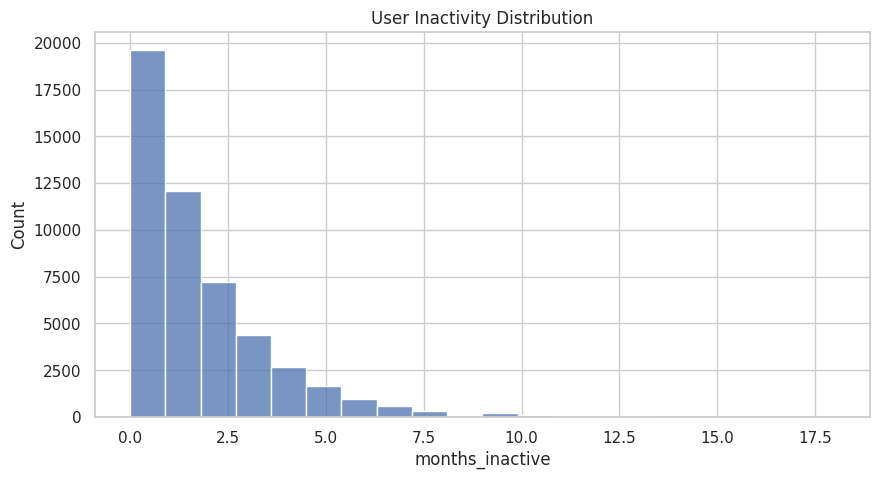

In [18]:
plt.figure(figsize=(10,5))

sns.histplot(df["months_inactive"], bins=20)

plt.title("User Inactivity Distribution")

plt.show()

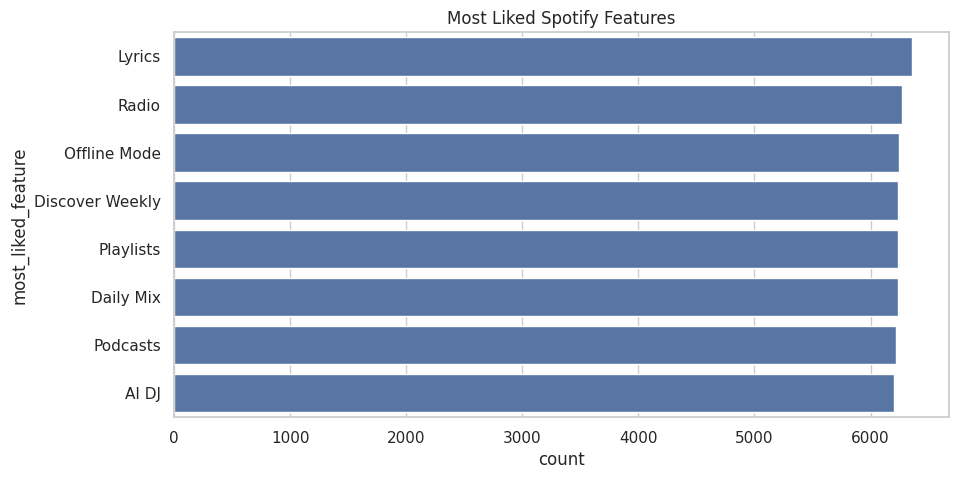

In [19]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=df,
    y="most_liked_feature",
    order=df["most_liked_feature"].value_counts().index
)

plt.title("Most Liked Spotify Features")

plt.show()

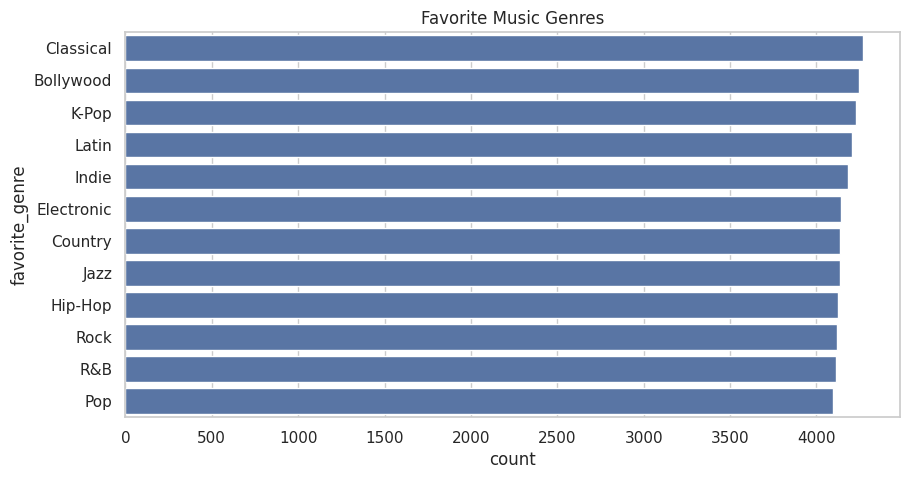

In [20]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=df,
    y="favorite_genre",
    order=df["favorite_genre"].value_counts().index
)

plt.title("Favorite Music Genres")

plt.show()

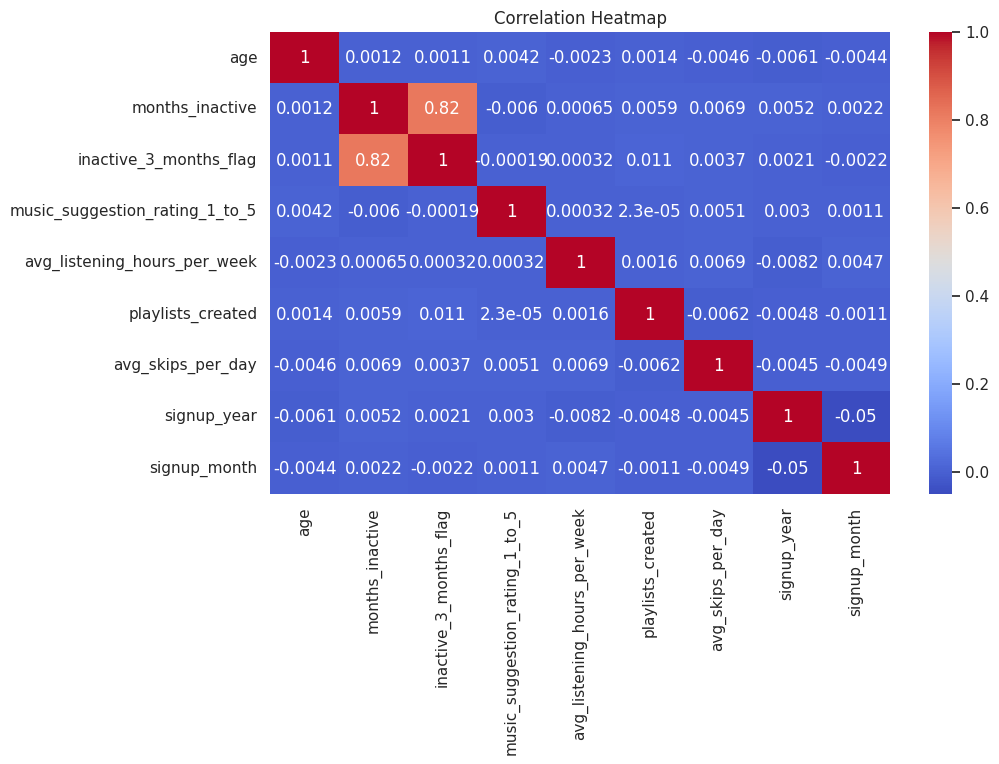

In [21]:
numeric_cols = df.select_dtypes(include=np.number)

plt.figure(figsize=(10,6))

sns.heatmap(
    numeric_cols.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

In [22]:
upgrade_analysis = df.groupby("subscription_type")[[
    "avg_listening_hours_per_week",
    "playlists_created",
    "music_suggestion_rating_1_to_5"
]].mean()

upgrade_analysis 

,avg_listening_hours_per_week,playlists_created,music_suggestion_rating_1_to_5
subscription_type,,,
Free,10.017634,7.990100,3.642575
Premium Duo,9.959186,7.951439,3.630171
Premium Family,9.963440,8.026774,3.622267
Premium Individual,9.972635,8.028013,3.652933
Student,9.951592,8.013286,3.659655


# Machine Learning

In [23]:
df_ml = df.copy()

cat_cols = df_ml.select_dtypes(include="object").columns

le = LabelEncoder()

for col in cat_cols:
    df_ml[col] = le.fit_transform(df_ml[col])

In [24]:
X = df_ml.drop(["inactive_3_months_flag","signup_date"], axis=1)
y = df_ml["inactive_3_months_flag"]

In [25]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [26]:
model = RandomForestClassifier()

model.fit(X_train, y_train)

RandomForestClassifier()

In [27]:
y_pred = model.predict(X_test)

print(confusion_matrix(y_test,y_pred))

print(classification_report(y_test,y_pred))

[[7834    0]
 [   0 2166]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      7834
           1       1.00      1.00      1.00      2166

    accuracy                           1.00     10000
   macro avg       1.00      1.00      1.00     10000
weighted avg       1.00      1.00      1.00     10000



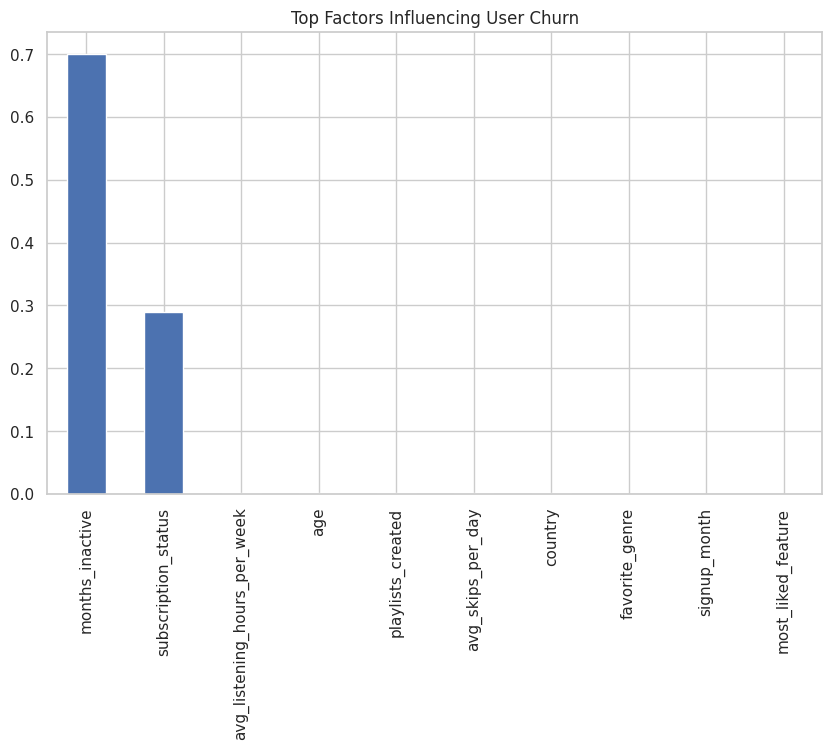

In [28]:
importance = pd.Series(
    model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

plt.figure(figsize=(10,6))

importance.head(10).plot(kind="bar")

plt.title("Top Factors Influencing User Churn")

plt.show()